# Практическое задание №1

Используйте данные из файла **StudentPerformanceFactors.csv** с информацией о студентах.

[Источник](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/code)

В нём содержатся следующие переменные:


| Название переменной | Описание переменной 
|:-------------------:|:------------------:|
| Hours_Studied | Number of hours spent studying per week |
| Attendance | Percentage of classes attended | 
| Parental_Involvement | Level of parental involvement in the student's education (Low, Medium, High)| 
| Access_to_Resources | Availability of educational resources (Low, Medium, High)| 
| Extracurricular_Activities | Participation in extracurricular activities (Yes, No).
| Sleep_Hours | Average number of hours of sleep per night.
| Previous_Scores |	Scores from previous exams.
| Motivation_Level |	Student's level of motivation (Low, Medium, High).
| Internet_Access |	Availability of internet access (Yes, No).
| Tutoring_Sessions |	Number of tutoring sessions attended per month.
| Family_Income |	Family income level (Low, Medium, High).
| Teacher_Quality |	Quality of the teachers (Low, Medium, High).
| School_Type |	Type of school attended (Public, Private).
| Peer_Influence |	Influence of peers on academic performance (Positive, Neutral, Negative).
| Physical_Activity |	Average number of hours of physical activity per week.
| Learning_Disabilities |	Presence of learning disabilities (Yes, No).
| Parental_Education_Level |	Highest education level of parents (High School, College, Postgraduate).
| Distance_from_Home |	Distance from home to school (Near, Moderate, Far).
| Gender |	Gender of the student (Male, Female).
| Exam_Score |	Final exam score.

Выполните, пожалуйста, следующие задания.

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [107]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df.info()
display(df.head())
display(df.describe())
display(df.describe(include=['object', 'string']))
print(f"Нулевых значений: \n{df.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


Нулевых значений: 
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


Задание 1. Опишите датасет (число наблюдений и переменных, пропущенных значений, типы данных, типы шкал переменных).
| Название переменной | Описание переменной | Характеристики переменной |
| :--- | :--- | :--- |
| **Часы_обучения / Hours_Studied** | Количество часов в неделю на учебу / Number of hours spent studying per week | Абсолютная шкала - данные имеют абсолютный ноль, и их можно численно сравнить. Dtype - int64 (тип integer размером в 64 бит), максимальное значение 44 часа, минимальное 1 говорит о наличии выбросов, но среднее 19.9 часов, в то время как квартиль в 50% 20 часов, а стандартное отклонение в ~6 часов говорит что выбросов не много и большая часть студентов учится в пределах 20 часов в неделю. Одна из основных характеристик, несмотря на возможность сильного отклонения вызванных некорректными данными при сборе. |
| **Посещаемость / Attendance** | Процент посещенных занятий / Percentage of classes attended | Абсолютная процентная шкала, данные в %, тип данных integer64. Среднее значение в районе 80% - это высокий показатель посещаемости, стандартное отклонение чуть больше 10% говорит о небольшом разбросе данных. Может послужить для оценки корреляции между посещаемостью и успеваемостью, с корректировкой на доступность к данным|
| **Вовлеченность_родителей / Parental_Involvement** | Уровень участия родителей: Низкий, Средний, Высокий / Level of parental involvement: Low, Medium, High | Порядковая (ординальная) шкала - ранжирует объекты, но не имеет возможности измерить их. Нет пропущенных значений, данные полные, мода - medium означает средний уровень включения большинства родителей в учебу студентов. Сомнительная характеристика, так как мы не знаем по каким критериям был выведен отбор, есть вероятность влияния оценочного суждения, которая может исказить статистику.|
| **Доступ_к_ресурсам / Access_to_Resources** | Доступность ресурсов: Низкая, Средняя, Высокая / Availability of educational resources: Low, Medium, High | Тип данных string. Так же порядковая шкала. Так же имеет низкий уровень доверия к данным, так как является субъективной характеристикой, мода - medium, количество почти 50% от всех данных почти гарантирует оценочный характер этого параметра. |
| **Внеучебная_деятельность / Extracurricular_Activities** | Участие во внеклассных мероприятиях: Да, Нет / Participation in extracurricular activities: Yes, No | Номинальная шкала - тип дихотомическая переменная. Количество студентов, принимающих участие во внеклассных мероприятиях (мода - "Yes" ) составляет 3938 из 6607, отсутствующих значений нет, чуть более 50% из всех студентов выборки участвовало хоть в каких-либо внеурочных мероприятиях. Данная сущность говорит о достаточно высокой активности студентов, может косвенно служить характеристикой для оценки психологического состояния студентов и в следствие быть шкалой измерения между двумя категориями: личностными данными/успеваемость |
| **Часы_сна / Sleep_Hours** | Среднее количество часов сна за ночь / Average number of hours of sleep per night | Тип данных int. Абсолютная шкала, среднее количество часов сна составило 7 часов с отклонением в 1.5 часа. Учитывая что рекомендуемой нормой, в среднем, можно считать 8 часов сна, то можно измерить влияние сильного отклонения от данного утверждения на психологическое состояние (оценочно) и влияния на учебу недостатка сна и/или пересыпания в сравнении с нормой (корреляция часы сна/успеваемость) |
| **Предыдущие_результаты / Previous_Scores** | Баллы за предыдущие экзамены / Scores from previous exams | 100-балльная абсолютная шкала, средний балл 75, говорит о высоком показателе, мало пригодно само по себе, очень высокие показатели могут говорить как об инициативности и высокой включенности учащихся, так и о низких критериях оценки преподавателей. В совокупности с данными о типе образовательного учреждения возможно могут служить для оценки "мотивированности студентов" во время учебы в частном заведении. |
| **Уровень_мотивации / Motivation_Level** | Уровень мотивации: Низкий, Средний, Высокий / Student's level of motivation: Low, Medium, High | Порядковая шкала. Субъективная характеристика самих студентов, значение моды - "medium", больше говорит о личности учащихся и не может являться полноценной характеристикой для анализа. |
| **Доступ_к_интернету / Internet_Access** | Наличие доступа к интернету: Да, Нет / Availability of internet access: Yes, No | Номинальная дихотомическая шкала. Имеет важную роль при оценке доступности к ресурсам в совокупности с `Access_to_Resources`. Так же, в некоторых случаях, может служить одной из характеристик "обеспеченности" студентов. Мода показателя - "Yes" с общим количеством 6108 из 6607 говорит о том что большая часть студентов имеет тот или другой доступ к интернету. |
| **Дополнительные_занятия / Tutoring_Sessions** | Количество занятий с репетитором в месяц / Number of tutoring sessions attended per month | Абсолютная шкала, тип данных int. Показатель количества занятий в месяц. Max - 8, Min - 0, среднее - 1.5 с отклонением 1.2. Большая часть студентов имела хотя бы 1 занятие в месяц, весьма специфические данные, как правило студент либо ходит к репетитору либо нет, ожидаемо сильное отклонение и медиану в районе 0, в этих же данных выходит, что половина студентов ходит как минимум 1 раз в месяц к преподавателю, что мало согласуется с реально возможными данными. Таким образом эти данные лучше либо избегать вообще, либо интерпретировать лишь их общее среднее (медианное) количество к общему количеству студентов, не может служить основой построения гипотез. |
| **Доход_семьи / Family_Income** | Уровень дохода семьи: Низкий, Средний, Высокий / Family income level: Low, Medium, High | Порядковая (ординальная) шкала. В совокупности с другими данными может быть рассмотрена в качестве характеристики влияния дохода в семье на учебу студента, либо как параметр личностные характеристики/успешность в учебе так как социальный статус в семье так же влияет и на внутренний мир студента. Интересный показатель, мода - "Low", freq - 2672. Говорит что доход семье в большинстве случаев низкий, но количество по отношению к общей выборке составляет ~40%, что говорит о нормированных данных, так как мы не знаем точную страну говорить о "среднем доходе большинства" довольно тяжело, поэтому его следует использовать только в совокупности с другими данными и желательно для подтверждения гипотезы а не как основные данные для ее построения.|
| **Качество_преподавания / Teacher_Quality** | Качество работы учителей: Низкое, Среднее, Высокое / Quality of the teachers: Low, Medium, High | Ординальная шкала, данные типа string - строковые данные, оценочное суждение студентов по качеству работы преподавателей, имеет пустые строки, но их количество незначительно и их удаления не должно повлиять на статистику. Так же как и все остальные данные содержащие "оценочные суждения" близится к среднему (мода - "medium"). Данные могут быть интерпретированы как подтверждение гипотезы по "доступности информации/успеваемость", но более никаких вариантов их использования я на данный момент не вижу. |
| **Тип_школы / School_Type** | Тип учебного заведения: Государственное, Частное / Type of school attended: Public, Private | Ординальная шкала, тип данных str. Мода - "public", большая часть учащихся ходит в государственное образовательное учреждение. Пропусков нет, одни из наиболее "надежных данных" в датасете, с однозначной интерпретацией. Могут служить для определения взаимосвязей между образовательными программами, уровнем дохода и успеваемостью. |
| **Влияние_сверстников / Peer_Influence** | Влияние сверстников: Положительное, Нейтральное, Отрицательное / Influence of peers: Positive, Neutral, Negative | Порядковая шкала, тип str. Судя по всему, также являющееся оценочным суждением, но не понятно кого родителей, учеников? Учитывая что мода - "positive", с количеством ~30-40% от общего числа, это оценка студентов на влияние своих сверстников. Поэтому ожидаемо завышение параметров, возможно значительное. Может служить как подтверждение гипотез, но в очень ограниченном состоянии. |
| **Физическая_активность / Physical_Activity** | Часов физической активности в неделю / Average number of hours of physical activity per week | Абсолютная шкала - определяет количество часов в неделю по физической активности. Среднее значение ~3 часа с отклонением в 1 час, так как мы не знаем что конкретно входит в эту активность (пока что) будем исходить из логики, что занятия физкультурой в образовательном учреждении так же входит в этот параметр, таким образом пускай и косвенно но значительное отклонение можно интерпретировать как плохое состояние здоровья или наоборот более высокие показатели как хорошие.|
| **Трудности_в_обучении / Learning_Disabilities** | Наличие трудностей в обучении: Да, Нет / Presence of learning disabilities: Yes, No | Номинальная дихотомическая шкала, тип данных str. Мода - "no", freq - 5912, эти данные говорят что подавляющая часть студентов, по их мнению, не испытывает проблем с учебой, это же подтверждается наличием высоких баллов у учеников. Так как идет явное отклонение от нормального в обоих случаях, это может свидетельствовать что выборка данных производилась не корректно, или среди учащихся с заведомо "сильной базой", что вряд ли соответствует нормальному сценарию. Так же стоит учитывать что данные распределены между учащимися разных групп как в социальном плане, так и в плане "уровня образования".|
| **Образование_родителей / Parental_Education_Level** | Уровень образования родителей: Школа, Колледж, Высшее / Highest education level of parents: High School, College, Postgraduate | Порядковая шкала, тип string. 50% всех родителей имеют высшее образование. Может послужить в гипотезах при проверке доступности информации к успешности в учебе или социального статуса родителей к успешности в учебе детей. |
| **Расстояние_от_дома / Distance_from_Home** | Расстояние до школы: Близко, Средне, Далеко / Distance from home to school: Near, Moderate, Far | Порядковая шкала, тип str. У большей части учащихся мода - "near", говорит о том что большая часть учащихся живет не подалеку от образовательного учреждения. Возможно существует корреляция между количеством часов затраченных на учебу в неделю и близостью к учебному учреждению. В довольно простой логике - чем ближе ты к образовательному учреждению, тем меньше времени ты затрачиваешь на дорогу до него, а значит остается большее количество времени на учебу. Сомнительный параметр, с ограниченными возможностями его применения. |
| **Пол / Gender** | Пол студента: Мужской, Женский / Gender of the student: Male, Female | Номинальная дихотомическая шкала, тип str. Мода - "male" чуть более 50% от общего числа, и являются сбалансированными данными. Можно интерпретировать как различие гендера по культурным и социальным явлениям на успеваемость и учебу. Так же возможна интерпретация по типу образовательного учреждения (как способ выборки по возрасту) на общее развитие и фильтрацией данных по гендеру. |
| **Балл_за_экзамен / Exam_Score** | Итоговый балл за экзамен / Final exam score | Абсолютная шкала, тип данных int. min - 55 mean - 67 с отклонением в 3.9 балла, max - 101. Максимум превышающий 100 шкалу может говорит о выбросах. В остальном данные примерно соответствуют реальности, если мы берем в учет что люди получившие оценки менее 50 баллов считаются не сдавшими, и не попали в выборку данного датасета.|


# Вывод

Данный датасет является синтетическим. В данном датасете 20 признаков (7 количественных и 13 категориальных), некоторые количественные переменные демонстрируют признаки нормального распределения, но без полного анализа однозначно утверждать нельзя. Большая часть метрик является субъективной оценкой самих учащихся на процесс своего обучения, что может повлиять на объективность анализа. Тем не менее совокупность нескольких факторов можно использовать для подтверждения гипотез, в ряде случаев. Так же некоторые показатели могут иметь различную интерпретацию в зависимости от контекста, что ограничивает возможность их использования. Таким образом данный датасет может быть рассматривать как репрезентативный преимущественно для демонстрационных или учебных целей, с возможностью использовать данные только в случае если они подтверждены иными достоверными фактами.

2. Проведите описательный анализ переменных датасета, используя подходящие методы анализа в зависимости от типа шкалы измерения переменной (частотный анализ данных, сводные таблицы, меры центральной тенденции и меры разброса, характеристики распределений переменных, графический анализ данных). Интерпретируйте полученные результаты. Обратите внимание, что анализ данных предполагает следующие этапы:
- постановка задачи и выбор переменных,
- обоснование выбора метода анализа,
- проведение расчётов,
- интерпретация результатов.

Например, я хотела бы проанализировать физическую активность студентов. Для этого я рассматриваю переменную "Physical_Activity". Поскольку она имеет метрическую шкалу измерения для ее анализа целесообразно построить гистограмму распределения значений и рассчитать описательные статистики. Далее делаете выводы на основе проведенных расчётов.

## Постановка задачи и выбор переменных
Учитывая данные, которые мы проанализировали, постановка задачи должна быть общей и охватывать максимальное количество параметров, что бы быть репрезентативной и исключить возможность неверного анализа из за структурных особенностей самого датасета. Но в то же время нельзя выдвигать гипотезы которые будут иметь чрезмерно широкий смысл, что может привести к возможности появления ошибки интерпретации большого потока данных. Поэтому предполагаю, что наилучшим вопросом будет тот, который охватывает от 3 до 5 параметров.

***Исследовательский вопрос:***
**Как социально-экономические факторы влияют на академическую успеваемость?**

**Выбор переменных:**
- **Балл_за_экзамен / Exam_Score**
- **Доход_семьи / Family_Income**
- **Тип_школы / School_Type**
- **Образование_родителей / Parental_Education_Level**
- **Вовлеченность_родителей / Parental_Involvement**

**Обоснования выбора переменных:**

Эти переменные создают основной вектор поставленного вопроса, взаимосвязь которых позволит судить о влиянии социально-экономических связей на оценки учащихся. Для удовлетворительного ответа на данный вопрос, мы должны проследить прямую корреляцию Доход семьи / Балл за экзамен. И далее мы должны интерпретировать его, в зависимости от полученного ответа. Дополнительно мы рассмотрим связь уровня образования родителей, и их вовлеченность в образовательный процесс с выявленной (или нет) зависимостью.

Для ответа на данный исследовательский вопрос, в идеале лучшим вариантом было бы ответить на ряд вопросов более узкого характера, которые прямо или коственно могли бы повлиять на результаты исследования. 

К таким вспомагательным вопросам я бы отнес:
1) *Как вовлеченность родителей влияет на успеваемость их детей?* Вовлеченность родителей может оказывать существенное влияние на образовательную деятельность детей, при подтверждении данного факта (подтверждении на данной выборке) мы можем использовать ее для более глубокого анализа влияния экономического фактора в связке с вовлеченностью родетелей, исключив неверную интерпретацию в случаях, когда один фактор вносит шум в исследования другого параметра.
2) *Существуют ли взаимосвязи, в этом датасете между данными о доходе семьи и параметров которые могут коственно указывать на нее?* К таким параметрам мы можем отнести: Physical_Activity (больше возможностей быть в платных секциях), Tutoring_Sessions (Занятия с репетитором часто имеет высокую цену).
3) *Какое влияние доход семьи оказывает на эмоциональный фон ребенка?* Высокий социальный статус, часто проявляеться и на личность ребенка, он может быть более уверен в себе, что может влиять на такие параметры как: Extracurricular_Activities (более общителен, больше проявляет активность), Peer_Influence (пускай и коственно, но оценка этого параметра как "положительная" в большей мере может так же говорить о эмоциональном фоне и восприятии ребенка), Motivation_Level (субективный параметр, прямо ни как не влияет на поставленный вопрос, но анализировать его мы будем несколько иначе, нам интересен он только как параметр эмоционального фона ребенка (как паказатель удовлетворенности жизни), высокие паказатели - могут означать позитивное мышление)
4) *Какое влияние оказывает тип школы на успеваемость? Являеться ли программа в частных образовательных учрждений более сложной?* Здесь поставленно два взимосвязанных вопроса. В случае с первым, мы имеем класическую делему при которой более состоятельные граждане могут учиться в более престижных учрждениях, просто из за наличия на нее средств. А вот второй же вопрос должен ответить, а повлияет ли это хоть на что то? Или может зависимости нет, и с точки образовательных программы они идентичны, либо же может окзаться наборот - образовательная программа сильнее в частных учрждениях, но и оценки тогда будут выставлять строже, а это приведет к тому что состоятельные граждане в среднем будут иметь меньше хороших результатов. Стоит так же учитывать что выборка имеет сильное накренеие по баллам в сторону положительного результата, так что в данном датасете влияние скорее всего будет незначительным, либо может вообще не наблюдаться.
5) *Как влияет образование родителей на доходы семьи? Какое влияние оказывает образование родителей (в связке с вовлеченностью родителей) на образования их детей?* Образование родителей, может иметь корреляцию с доходом семьи, в случае его обнаружения мы так должны будем ответить на второй вопрос, помагает ли хорошее образования обеспеченных родителей, учиться их детям. Но этот вопрос имеет смысл только при высоком паказателе вовлеченности родителей в обучающий процесс своих детей. Таким образом в этих двух вопросах мы должны будем проследить взаимосвезь: Образования родителей --> Доход семьи --> Балл за экзамен 

Так как данный проект носит учебный характер, основное внимание уделяется ключевой модели. Остальные вспомогательные вопросы рассматриваются  лишь в теоретической части и не включаются в основное исследование, чтобы избежать избыточной сложности анализа.

# Обоснование выбора методов анализа

Для исследования влияния социально-экономических факторов на академическую успеваемость (через переменную `Exam_Score`) выбрана стратегия статистического анализа, основанная на типах шкал данных и характере их распределения.

#### 1. Подготовка и предварительный анализ (описательный анализ был выполнен в задании 1)
Несмотря на проведенный ранее описательный анализ, на данном этапе выполняется обязательная очистка данных:
* **Удаление пропусков:** Исключение неполных наблюдений для обеспечения корректности работы статистических тестов.
* **Фильтрация выбросов:** Удаление аномальных значений в переменной `Exam_Score` (значения > 100), которые могут сместить средние показатели и исказить результаты корреляционного анализа.

#### 2. Анализ распределения целевой переменной
Выбор методов для поиска взаимосвязей зависит от того, подчиняется ли переменная `Exam_Score` закону нормального распределения.
* **Методы проверки:** * Визуальный анализ (Гистограмма и Q-Q plot).
    * Статистический тест Шапиро-Уилка (H_0: данные распределены нормально).
* **Обоснование:** Если распределение окажется ненормальным, использование классических параметрических методов (например, корреляции Пирсона) даст ложный результат.

#### 3. Исследование взаимосвязей (Корреляционный анализ)
Для оценки влияния факторов на успеваемость используются методы, соответствующие порядковым и номинальным шкалам:
* **Для порядковых факторов (`Family_Income`, `Parental_Education`, `Parental_Involvement`) и успеваемости:**
    * **Метод:** Ранговая корреляция Спирмена.
    * **Обоснование:** Позволяет оценить наличие и силу монотонной связи между рангами (уровнями) дохода/образования и баллами.
* **Для номинального фактора (`School_Type`) и успеваемости:**
    * **Метод:** Сравнение распределений в группах Public/Private с помощью ящичковых диаграмм (Boxplots) и статистическая проверка значимости различий (U-критерий Манна-Уитни или t-тест).
    * **Обоснование:** Позволяет определить, дает ли тип учебного заведения статистически значимое преимущество в баллах.
* **Для анализа связей между самими факторами:**
    * **Метод:** Критерий Хи-квадрат Пирсона.
    * **Обоснование:** Применяется для поиска зависимостей между категориальными переменными (например, связь между уровнем дохода и типом школы).

#### 4. Визуализация зависимостей
Для наглядного подтверждения расчетов используются **ящичковые диаграммы (Boxplots)**. Они позволяют сравнить распределение баллов внутри разных групп (например, "Low Income" vs "High Income") и увидеть различия в медианах успеваемости.

In [108]:
"""----- Блок очистки данных от пропусков и аномалий (остаток от описательного анализа) -----"""
df1 = df.copy() 
# Удаляем строки с пропущенными значениями
df1.dropna(inplace=True)  
# удалим выбросы из переменной Exam_Score
df1 = df1[df1['Exam_Score'] <= 100]

c:\Users\Happy\OneDrive\Рабочий стол\ОФ Анализ данных 2026\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6377.
  res = hypotest_fun_out(*samples, **kwds)


Статистика теста: 0.9055
p-value: 1.1745e-52


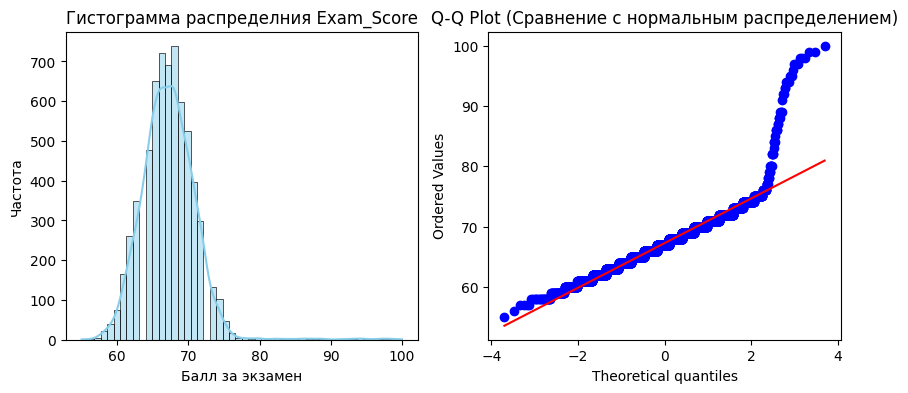

In [109]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df1['Exam_Score'], kde=True, bins=50, color='SkyBlue')
plt.title("Гистограмма распределния Exam_Score")
plt.xlabel("Балл за экзамен")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
stats.probplot(df1['Exam_Score'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Сравнение с нормальным распределением)')

stat, p_value = stats.shapiro(df1['Exam_Score'])

print(f"Статистика теста: {stat:.4f}")
print(f"p-value: {p_value:.4e}")


### Анализ полученных данных
Распределение баллов за экзамен близко к нормальному, центральная часть симметрична (среднее ~67 баллов), но имеет правосторонюю ассиметрию и большой правый хвост (из-за высоких баллов). Q-Q plot подтверждает, что отклонения от нормальности заметны только на хвостах (незначительное умеренное отклонение в левом хвосте, и очень сильное откланение в правом). 

Тест Шапиро-Уилка так же подтверждает визуальные данные: 
    - p-value: 1.1745e-52 < 0.05 - данные не имеют нормального расспределения
    - статистика теста Шапиро-Уилка 0.9055 (значения в диапозоне от 0 - 1, где 1 0 идеальная нормальность) Данное значение показывает что данные не сильно откланяются от нормального распределения. 

*P.S:* Стоит отметить что тест показал предупреждение о большой выборке, N > 5000, что может повлиять на результаты рассчета p-value, однако учитывая то, что эти данные соответствуют остальным тестам, мы берем их во внимания и интопретируем как верные.

Таким образом, данные близки в нормальному, и в ряде случаев из можно использовать для параметрических методов. Однако учитывая саму гипотезу которую мы проверяем, применение этих методов может привести к искаженным результатам. Поэтому в данном анализе мы используем мы прибегнем к непараметрическому анализу - коэффициенту корреляции Спирмена.

Корреляция (Доход семьи / Балл): 0.098, p-value: 0.0000
Корреляция (Образование родителей / Балл): 0.118, p-value: 0.0000


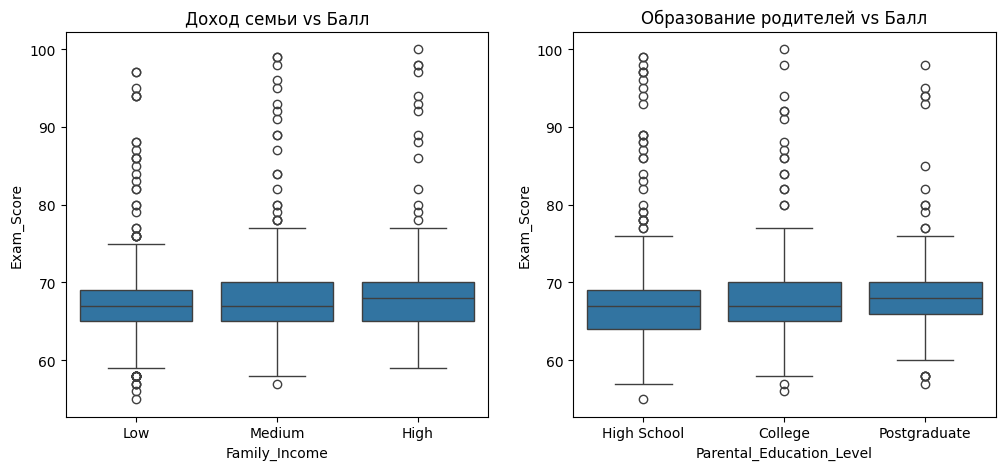

In [110]:
income_map = {
    'Low' : 0,
    'Medium' : 1,
    'High' : 2
}
edu_map = {
    'High School' : 0,
    'College' : 1,
    'Postgraduate' : 2
} 

df1['Income_Rank'] = df1['Family_Income'].map(income_map)
df1['Education_Rank'] = df1['Parental_Education_Level'].map(edu_map)


corr_income, p_inc = stats.spearmanr(df1['Income_Rank'], df1['Exam_Score'])
corr_edu, p_edu = stats.spearmanr(df1['Education_Rank'], df1['Exam_Score'])

print(f"Корреляция (Доход семьи / Балл): {corr_income:.3f}, p-value: {p_inc:.4f}")
print(f"Корреляция (Образование родителей / Балл): {corr_edu:.3f}, p-value: {p_edu:.4f}")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Family_Income', y='Exam_Score', data=df1, order=['Low', 'Medium', 'High'])
plt.title('Доход семьи vs Балл')

plt.subplot(1, 2, 2)
sns.boxplot(x='Parental_Education_Level', y='Exam_Score', data=df1, order=['High School', 'College', 'Postgraduate'])
plt.title('Образование родителей vs Балл')
plt.show()

### Анализ полученных данных

Анализ ящика с усами по Доходу семьи / Балл:  
Медианная линия показывает, что дети людей с высоким доходом в среднем получают чуть большую оценку, чем остальные. У детей со средним и низким доходом медианы почти одинаковые. Наибольший разброс данных (хотя и незначительно) присутствует у детей среднего достатка. Стоит обратить внимание на выбросы: значительная часть выбросов с очень низкими баллами именно у учащихся с низким доходом, при этом у детей с высоким доходом таких почти нет. Выбросы с наиболее высокими баллами тоже имеют возрастающую структуру - от низкого дохода к высокому их становится больше. Тем не менее общие показатели находятся примерно в одном диапазоне, и явной ярко-выраженной корреляции не наблюдается.

Анализ ящика с усами по Образованию родителей / Балл:  
Медианная линия здесь тоже почти одинаковая по всем трём группам - чуть выше у родителей с аспирантурой, но разница минимальная (где-то 1 - 2 балла). Разброс оценок (высота ящика) примерно одинаковая во всех категориях - нет такой группы, где дети сильно отличаются друг от друга по баллам. Выбросы вниз (очень низкие баллы) встречаются везде примерно одинаково, а выбросы вверх (высокие баллы) тоже распределены равномерно. В целом картина ещё более плоская, чем по доходу - уровень образования родителей почти не влияет на результат ребёнка.  

Корреляция (Спирмен):  
Доход семьи / Балл - р = 0.098 (очень слабая положительная), p-value примерно 0.0000 
Образование родителей / Балл - р = 0.118 (тоже очень слабая положительная), p-value примерно 0.0000  

Вывод:  
Оба фактора имеют **очень слабое положительное влияние** на балл за экзамен. Связь статистически значима (благодаря огромной выборке), но по силе практически несущественна. На графиках это видно особенно хорошо - медианы почти не отличаются, разброс похожий, а выбросы не создают явной тенденции. Можно сказать, что ни доход семьи, ни образование родителей в этих данных не являются условием успеха на экзамене.




U-статистика: 4230663.5
p-value теста Манна-Уитни: 0.2460


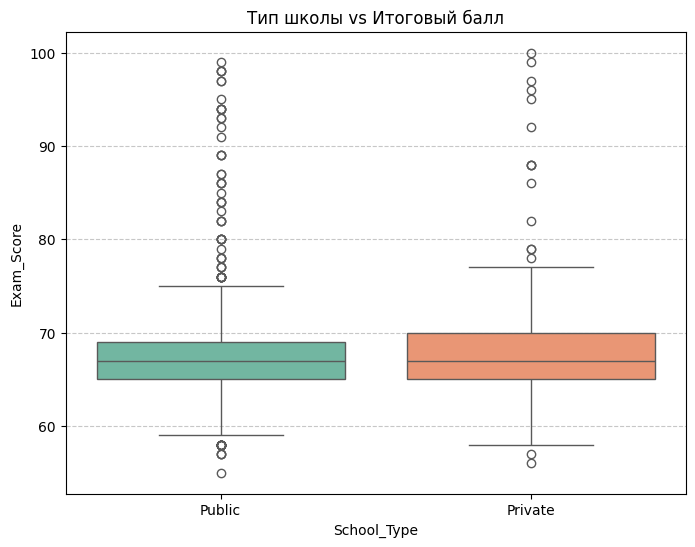


Средние баллы по типам школ:
School_Type
Private    67.316358
Public     67.216332
Name: Exam_Score, dtype: float64


In [111]:
# 1. Сравнение групп с помощью теста Манна-Уитни
public_scores = df1[df1['School_Type'] == 'Public']['Exam_Score']
private_scores = df1[df1['School_Type'] == 'Private']['Exam_Score']

stat_mw, p_mw = stats.mannwhitneyu(public_scores, private_scores)

print(f"U-статистика: {stat_mw}")
print(f"p-value теста Манна-Уитни: {p_mw:.4f}")

# 2. Визуализация
plt.figure(figsize=(8, 6))
sns.boxplot(x='School_Type', y='Exam_Score', data=df1, hue='School_Type', palette='Set2')
plt.title('Тип школы vs Итоговый балл')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Расчет средних
print("\nСредние баллы по типам школ:")
print(df1.groupby('School_Type')['Exam_Score'].mean())

#### Анализ полученных данных

Boxplot показывает, что медианные баллы за экзамен в государственных (Public) и частных (Private) школах практически одинаковые (~67-68 баллов). Разброс оценок тоже схожий.

У частных школ чуть меньше очень низких баллов (нижний край ящика и усов выше) и чуть больше очень высоких результатов (верхние выбросы чаще доходят до 95-100).

Однако тест Манна-Уитни не выявил статистически значимой разницы между группами (U = 4230663.5, p-value = 0.2460 > 0.05).

Средние баллы отличаются всего на 0.1 балла (Private 67.32 vs Public 67.22).

**Вывод:** 
тип школы (государственная или частная) не оказывает заметного влияния на итоговый балл за экзамен в этих данных.

Таблица сопряженности (Количество студентов):
School_Type    Private  Public
Family_Income                 
High               365     864
Low                803    1779
Medium             776    1790

Хи-квадрат: 0.8908
p-value: 0.6406


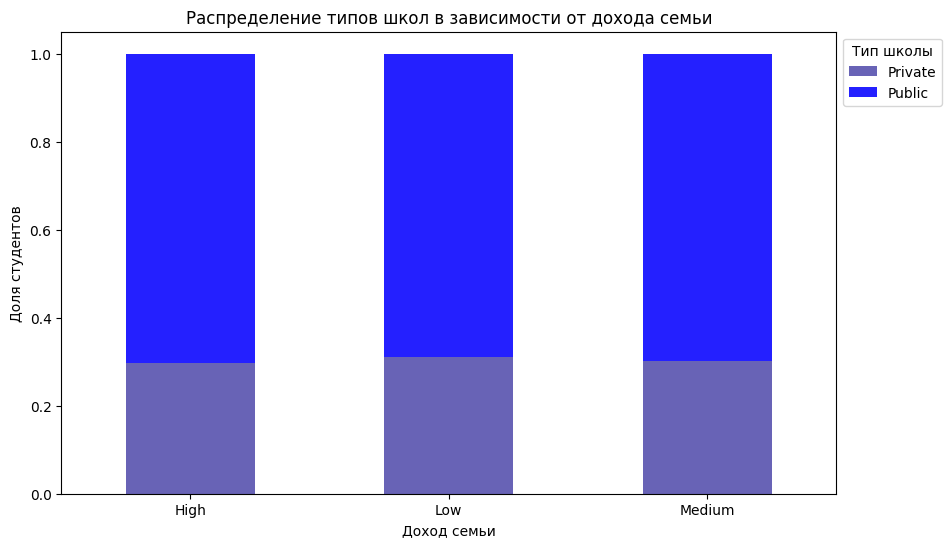

In [112]:
# 1. Таблица сопряженности
contingency_table = pd.crosstab(df1['Family_Income'], df1['School_Type'])

# 2. Тест Хи-квадрат
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("Таблица сопряженности (Количество студентов):")
print(contingency_table)
print(f"\nХи-квадрат: {chi2:.4f}")
print(f"p-value: {p_chi2:.4f}")

# 3. столбчатая диаграмма
contingency_table_pct = pd.crosstab(df1['Family_Income'], df1['School_Type'], normalize='index')
contingency_table_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#6863b6", "#0400ffdf"])

plt.title('Распределение типов школ в зависимости от дохода семьи')
plt.ylabel('Доля студентов')
plt.xlabel('Доход семьи')
plt.legend(title='Тип школы', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

#### Анализ полученных данных

Столбчатая диаграмма показывает, что доля студентов в частных школах (Private) составляет примерно 30% во всех группах дохода семьи. Разница между группами минимальна и визуально не заметна.

Тест хи-квадрат не выявил статистически значимой связи между доходом семьи и типом школы (x^2 = 0.8908, p-value = 0.6406 > 0.05).
Вывод: в этих данных доход семьи практически не влияет на выбор между государственной и частной школой. Доля частных школ стабильна ≈30% независимо от уровня дохода.

Средние баллы (Доход семьи vs Вовлеченность родителей):


Parental_Involvement,High,Low,Medium
Family_Income,,,
Low,67.642091,66.063291,66.734996
Medium,68.324288,66.253521,67.260511
High,68.662890,67.220833,67.567610


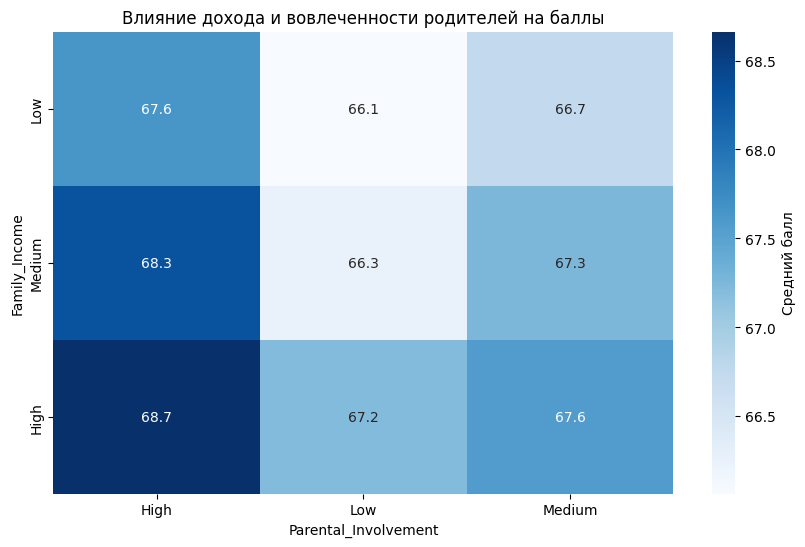

In [113]:
# 1. Сводная таблица: Средний балл в зависимости от дохода и вовлеченности родителей
pivot_involvement = df1.pivot_table(values='Exam_Score', 
                                     index='Family_Income', 
                                     columns='Parental_Involvement', 
                                     aggfunc='mean').reindex(['Low', 'Medium', 'High'])

print("Средние баллы (Доход семьи vs Вовлеченность родителей):")
display(pivot_involvement)

# 2. Тепловая карта (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_involvement, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Средний балл'})
plt.title('Влияние дохода и вовлеченности родителей на баллы')
plt.show()


#### Анализ полученных данных

Точечный график и тепловая карта показывают, что и доход семьи, и вовлечённость родителей имеют небольшое положительное влияние на итоговый балл за экзамен.

Средний балл растёт от Low к High но незначительно примерно на один балл. Такой же результат дает высокая вовлеченность родителей. 

Самый высокий средний балл (68.7) - у High Income + High Involvement.

Самый низкий (66.1) - у Low Income + Low Involvement.

Общая разница между крайними комбинациями примерно 2.6 балла - влияние обоих факторов слабое и аддитивное (нет сильного взаимодействия).

Визуально и численно связь заметна, но не является залогом успеха на экзамене.

### Общий вывод по анализу факторов, влияющих на балл за экзамен

Все рассмотренные факторы - доход семьи, образование родителей, тип школы и вовлечённость родителей - показывают **очень слабое влияние** на итоговый балл.

- Доход семьи и образование родителей дают **минимальный прирост** (р примерно 0.1, медианы почти не отличаются, разброс похожий).  
  У детей из обеспеченных семей и с образованными родителями чуть меньше провалов и чуть больше высоких баллов, но в среднем разница всего 1 - 2 балла. Явной зависимости нет.

- Тип школы (Public vs Private) не играет роли: медианы примерно 67 - 68, разброс одинаковый, тест Манна-Уитни показывает p = 0.246 (разницы нет).  
  Доля частных школ стабильна примерно 30% во всех группах дохода - хи-квадрат p = 0.64 подтверждает: связь с доходом отсутствует.

- Вовлечённость родителей влияет чуть заметнее остальных факторов: высокая вовлечённость стабильно даёт +1 - 1.5 балла по сравнению с низкой (независимо от дохода).  
  Но даже здесь общий диапазон изменений остаётся небольшим - максимум 2.6 балла между крайними комбинациями (High Income + High Involvement vs Low Income + Low Involvement).

Распределение баллов близко к нормальному в центральной части (среднее примерно 67), но с правосторонней асимметрией и тяжёлым правым хвостом. Тесты на нормальность отвергают гипотезу из-за большой выборки (n = 6377), но визуально отклонения не критичны.

Итог: ни один из факторов сам по себе **не является определяющим** для успеха на экзамене. Скорее всего, балл больше зависит от других вещей - личной подготовки, мотивации, качества преподавания или просто удачи в день экзамена. В этих данных социальные и семейные характеристики дают лишь небольшой фон.

3. Ответьте на вопросы (возможно, на некоторые из них Вы уже ответили в предыдущем пункте):
    - Какой процент студентов имеют высокую мотивированию?
    - Какого соотношение числа студентов с разным уровнем вовлеченности родителей в их обучение по группам уровня дохода семьи?
    - Наблюдается ли взаимосвязь между числом часов сна ночью и посещаемостью занятий?
    - Как различаются оценки юношей и девушек, живущих в разной удаленности от места обучения?
    - Какова специфика распределения финальных оценок за экзамен?
    - Наблюдается ли взаимосвязь между уровнем мотивации студентов и качеством преподавания?
    - Какими характеристиками обладают студенты-отличники (сами определите каких студентов отнести к отличникам)?
    - Какие факторы положительно взаимосвязаны с результатами экзамена (на этом этапе мы изучаем взаимосвязи на основе описательного анализа данных)?
    - Какие переменные имеют распределение, близкое к нормальному?
    - В распределении значений каких метрических переменных наблюдается асимметрия?
    

In [114]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df.info()
display(df.head())
display(df.describe())
display(df.describe(include=['object', 'string']))
print(f"Нулевых значений: \n{df.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


Нулевых значений: 
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


### Какой процент студентов имеют высокую мотивированию?

In [115]:
percent = df['Motivation_Level'].value_counts(normalize=True)*100
print(percent)

Motivation_Level
Medium    50.718934
Low       29.317391
High      19.963675
Name: proportion, dtype: float64


### Наблюдение  

Motivation_Level|%|
|-|-|
Medium  |  50.718934|
Low     |  29.317391|
High    |  19.963675|

Более половины студентов (50.7%) оценивают свой уровень мотивации как средний.
Высокую мотивацию демонстрируют лишь около 20% студентов, что является наименьшей долей среди всех категорий.

В данных наблюдаеться сильный перекос в сторону средних значений, учитывая что эта колонка показывает оценочное суждение самих студентов более чем вероятно что большинство людей несмогла четко определить состояние своей мотивации, что способствовало высокой концентрации ответов в категории "Medium"

### Какого соотношение числа студентов с разным уровнем вовлеченности родителей в их обучение по группам уровня дохода семьи?

In [116]:
pd.crosstab(df['Family_Income'], df['Parental_Involvement'], normalize='index')*100

Parental_Involvement,High,Low,Medium
Family_Income,,,
High,29.078014,19.779354,51.142632
Low,28.742515,21.369760,49.887725
Medium,28.919730,19.317329,51.762941


### Наблюдения

Во всех группах дохода доминирует средний уровень вовлеченности родителей (~ 50%), различия внутри групп колеблется в незначительном диапозоне (1-3%). Это говорит о том, что распределение уровня вовлеченности родителей практически не зависит от уровня дохода семьи.

### Наблюдается ли взаимосвязь между числом часов сна ночью и посещаемостью занятий?

In [117]:
corr, p = stats.spearmanr(df['Sleep_Hours'], df['Hours_Studied'])
print(f"Коэффициент Спирмена: {corr:.4f}, p_value: {p:.4f}")

corr, p = stats.pearsonr(df['Sleep_Hours'], df['Hours_Studied'])
print(f"Коэффициент Пирсона: {corr:.4f}, p_value: {p:.4f}")


Коэффициент Спирмена: 0.0112, p_value: 0.3633
Коэффициент Пирсона: 0.0110, p_value: 0.3723


### Наблюдения
Анализ показал что видимой взаимосвязи нет, коэффициент Пирсона (тест на линейную связь) а так же коэфициент Спирмена (тест на монотонную связь) имеют около нулевые значения. 

### Как различаются оценки юношей и девушек, живущих в разной удаленности от места обучения?

Distance_from_Home  Gender
Far                 Female    66.153025
                    Male      66.684350
Moderate            Female    66.917563
                    Male      67.027562
Near                Female    67.615572
                    Male      67.436161
Name: Exam_Score, dtype: float64


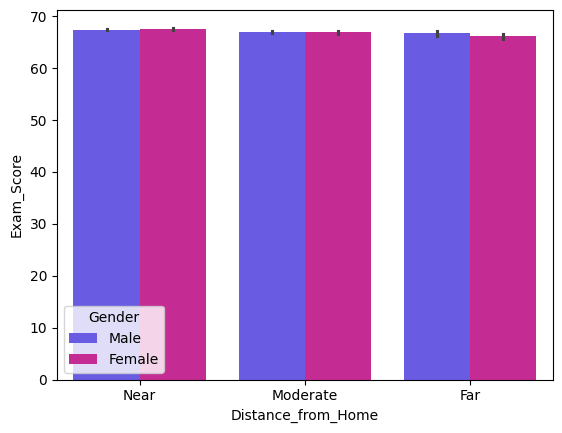

In [118]:
stats_gender = df.groupby(['Distance_from_Home', 'Gender'])['Exam_Score'].mean()
sns.barplot(x='Distance_from_Home', y='Exam_Score', hue='Gender', data=df, palette=["#5846F8","#DD139D"])
print(stats_gender)

### Наблюдения
"Идеальное распределенние" - примерно так можно охарактеризовать подобные данные, не уверен что в реальных условиях подобное возможно, различие между группами минимальное.

Средние баллы эзамена не имеют существенной корреляции от пола студентов или удаленности от места обучения.

### Какова специфика распределения финальных оценок за экзамен?

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


<Axes: xlabel='Exam_Score', ylabel='Count'>

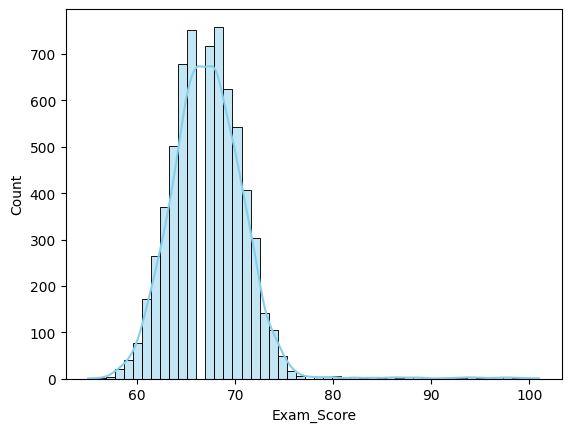

In [119]:
print(df['Exam_Score'].describe())
sns.histplot(df['Exam_Score'], kde=True, bins=50, color='SkyBlue')

### Наблюдения
Минимальная оценка min - 55, среднее mean - 67 с отклонением в 3.9 балла, max - 101. Максимум превышающий 100 шкалу может говорить о выбросах. В остальном данные примерно соответствуют реальности, если мы берем в учет что люди получившие оценки менее 50 баллов считаются не сдавшими, и не попали в выборку данного датасета. Данные тяготеют к нормальному распределению, но таковым не являются из-за сильного правостороннего ассиметрии и большого хвоста.

### Наблюдается ли взаимосвязь между уровнем мотивации студентов и качеством преподавания

In [120]:
table = round(pd.crosstab(df['Teacher_Quality'], df['Motivation_Level'], normalize='index')*100, 2)
display(table)
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Хи-квадрат: {chi2:.4f}, Степени свободы: {dof}, p-value: {p:.4f}")
print("Ожидаемые частоты:")
print(expected)

Motivation_Level,High,Low,Medium
Teacher_Quality,,,
High,20.80,29.89,49.31
Low,20.40,23.74,55.86
Medium,19.54,29.89,50.57


Хи-квадрат: 1.4120, Степени свободы: 4, p-value: 0.8421
Ожидаемые частоты:
[[20.24666667 27.84       51.91333333]
 [20.24666667 27.84       51.91333333]
 [20.24666667 27.84       51.91333333]]


### Наблюдения
- Ожидаемые частоты почти совподают с наблюдаемыми. 
- Процентное распределение практически одинаково во всех группах. 
- p-value > 0.05 и не показывает статистическую значимость.

В данном датасете уровень мотивации студентов не имеет значимой зависимости от качества образования.

### Какими характеристиками обладают студенты-отличники (сами определите каких студентов отнести к отличникам)?

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,48.000000,48.000000,48,48,48,48.000000,48.000000,48,48,48.000000,48,48,48,48,48.000000,48,48,48,48,48.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,20,22,33,NaN,NaN,23,43,NaN,19,26,37,21,NaN,40,23,28,27,NaN
mean,19.500000,79.041667,NaN,NaN,NaN,6.875000,73.812500,NaN,NaN,1.520833,NaN,NaN,NaN,NaN,2.666667,NaN,NaN,NaN,NaN,89.666667
std,6.562304,11.343680,NaN,NaN,NaN,1.510601,16.380653,NaN,NaN,1.184826,NaN,NaN,NaN,NaN,1.098032,NaN,NaN,NaN,NaN,6.405893
min,1.000000,61.000000,NaN,NaN,NaN,4.000000,52.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,80.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.000000,56.750000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,84.000000
50%,20.500000,76.000000,NaN,NaN,NaN,7.000000,75.500000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,89.000000
75%,24.250000,90.000000,NaN,NaN,NaN,8.000000,90.250000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,95.000000


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89
404,17,77,Low,High,Yes,5,53,Medium,Yes,2,High,Medium,Public,Neutral,3,No,College,Near,Male,86
529,15,83,Medium,Medium,No,7,97,Medium,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Female,97
558,22,70,Low,Medium,No,7,53,Low,Yes,1,Low,Medium,Public,Positive,3,No,High School,Near,Female,83


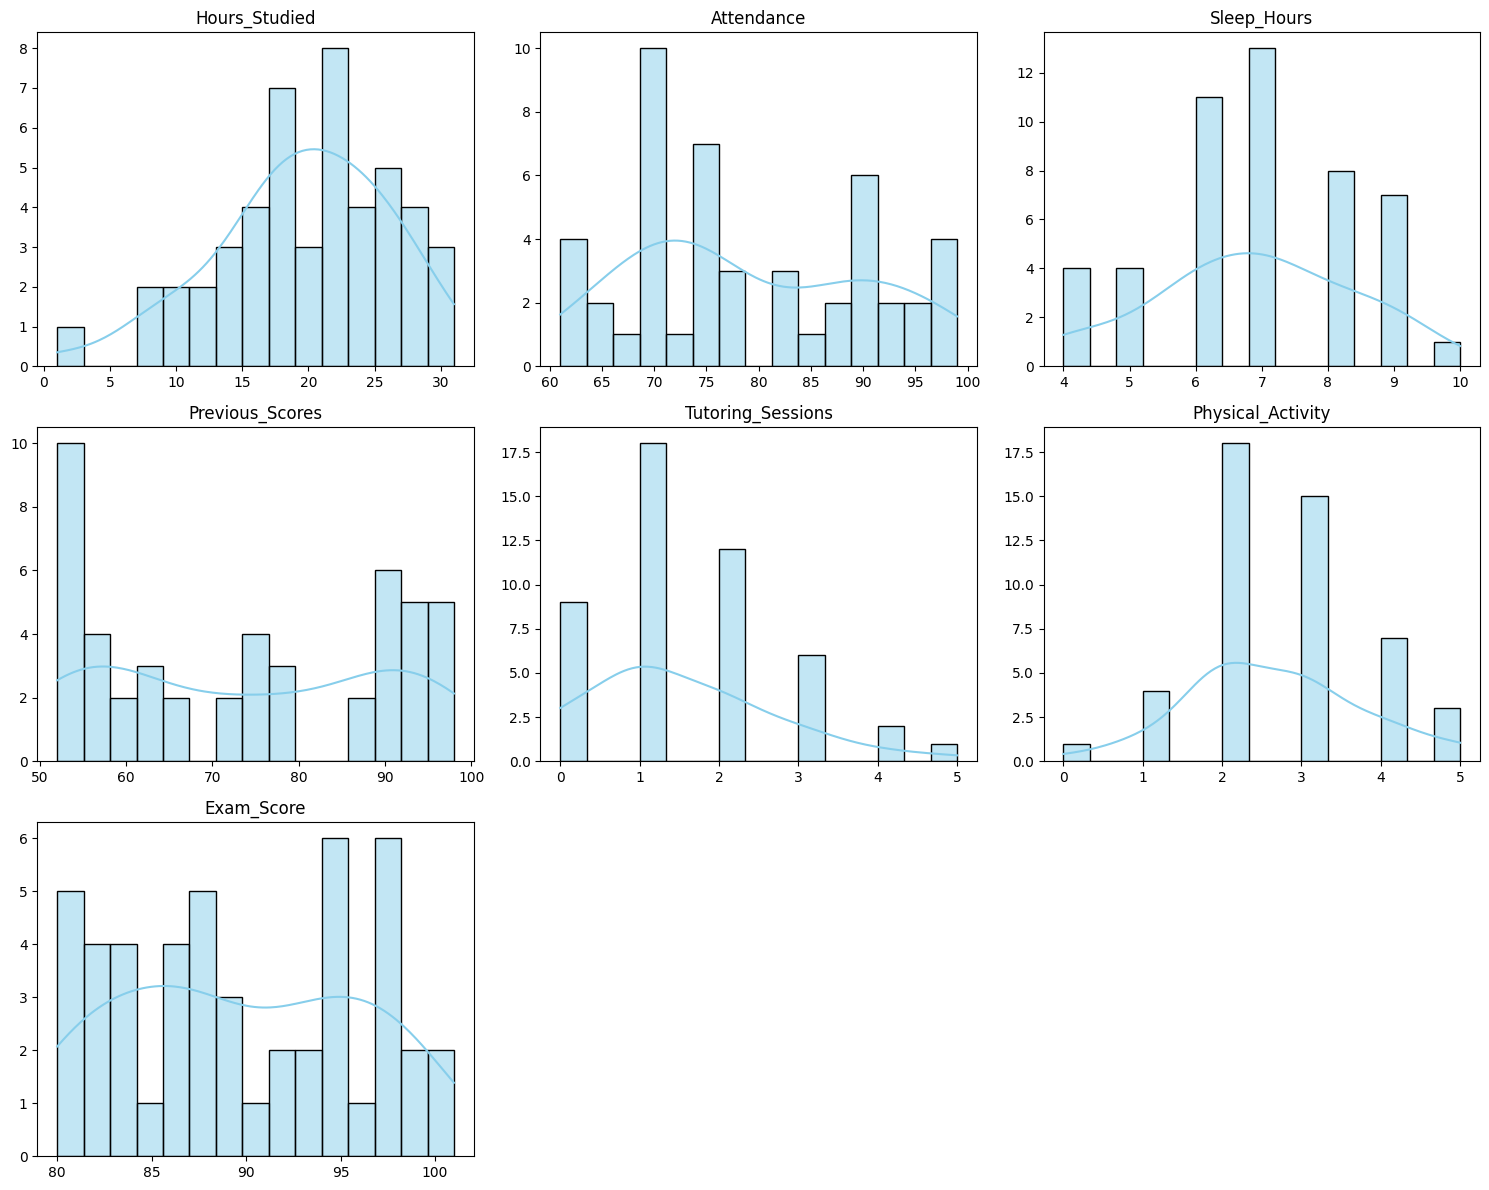

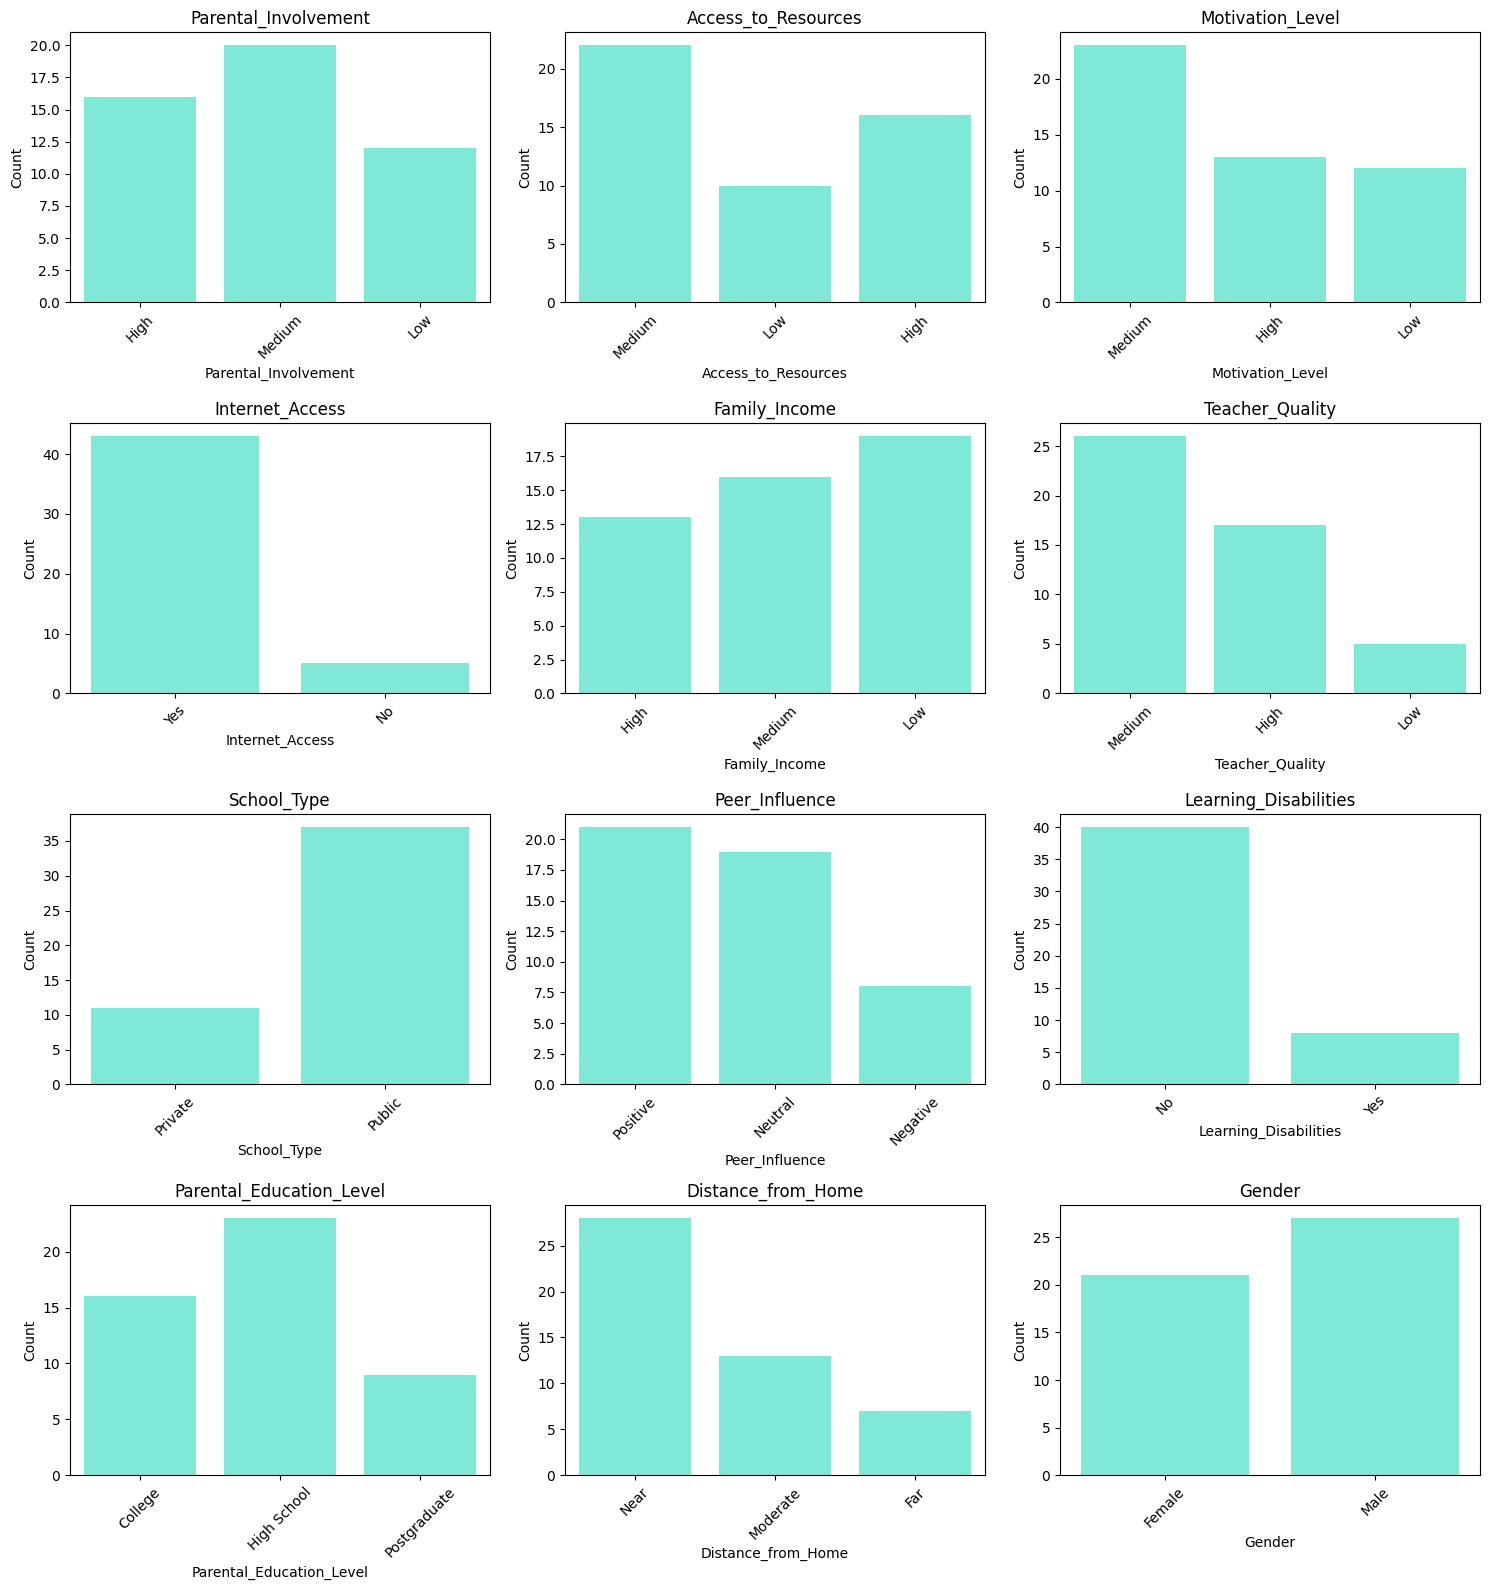

In [121]:
df_students_top = df[df['Exam_Score'] >= 80]
display(df_students_top.describe(include='all'))
display(df_students_top.head())

numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df_students_top[col], kde=True, color='skyblue', bins=15)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 
            'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 
            'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 
            'Distance_from_Home', 'Gender']

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(x=col, data=df_students_top, color="#6FF9E2")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


### Наблюдения
В выборку топ-отличников попало 48 студентов.
- Средний балл за экзамен составил - 89 баллов
- В среднем студенты учатся 20 часов в неделю
- Уровень посещаемости отличников держиться на 80%
- Предыдущие результаты в среднем ~75 баллов
- Физическая активность 2-3 часа в неделю

По категориальным данным серезных отличий между отличниками и остальными студентами так же не наблюдается, все показатели в среднем прямопропорциональны данным остальных студентов, не имеющих высоких баллов. 
Большинство студентов живет близко к учебному заведению и неиспытывает проблем с учебой. Доступ к ресурсам и качество образования уверенно держиться на средних показателях. Уровень мотивации отличников так же не отличается от остальных студентов устойчиво находясь на среднем уровне.

### Какие факторы положительно взаимосвязаны с результатами экзамена (на этом этапе мы изучаем взаимосвязи на основе описательного анализа данных)?

Exam_Score           1.000000
Attendance           0.672366
Hours_Studied        0.480956
Previous_Scores      0.191941
Tutoring_Sessions    0.163940
Physical_Activity    0.029150
Sleep_Hours         -0.007629
Name: Exam_Score, dtype: float64


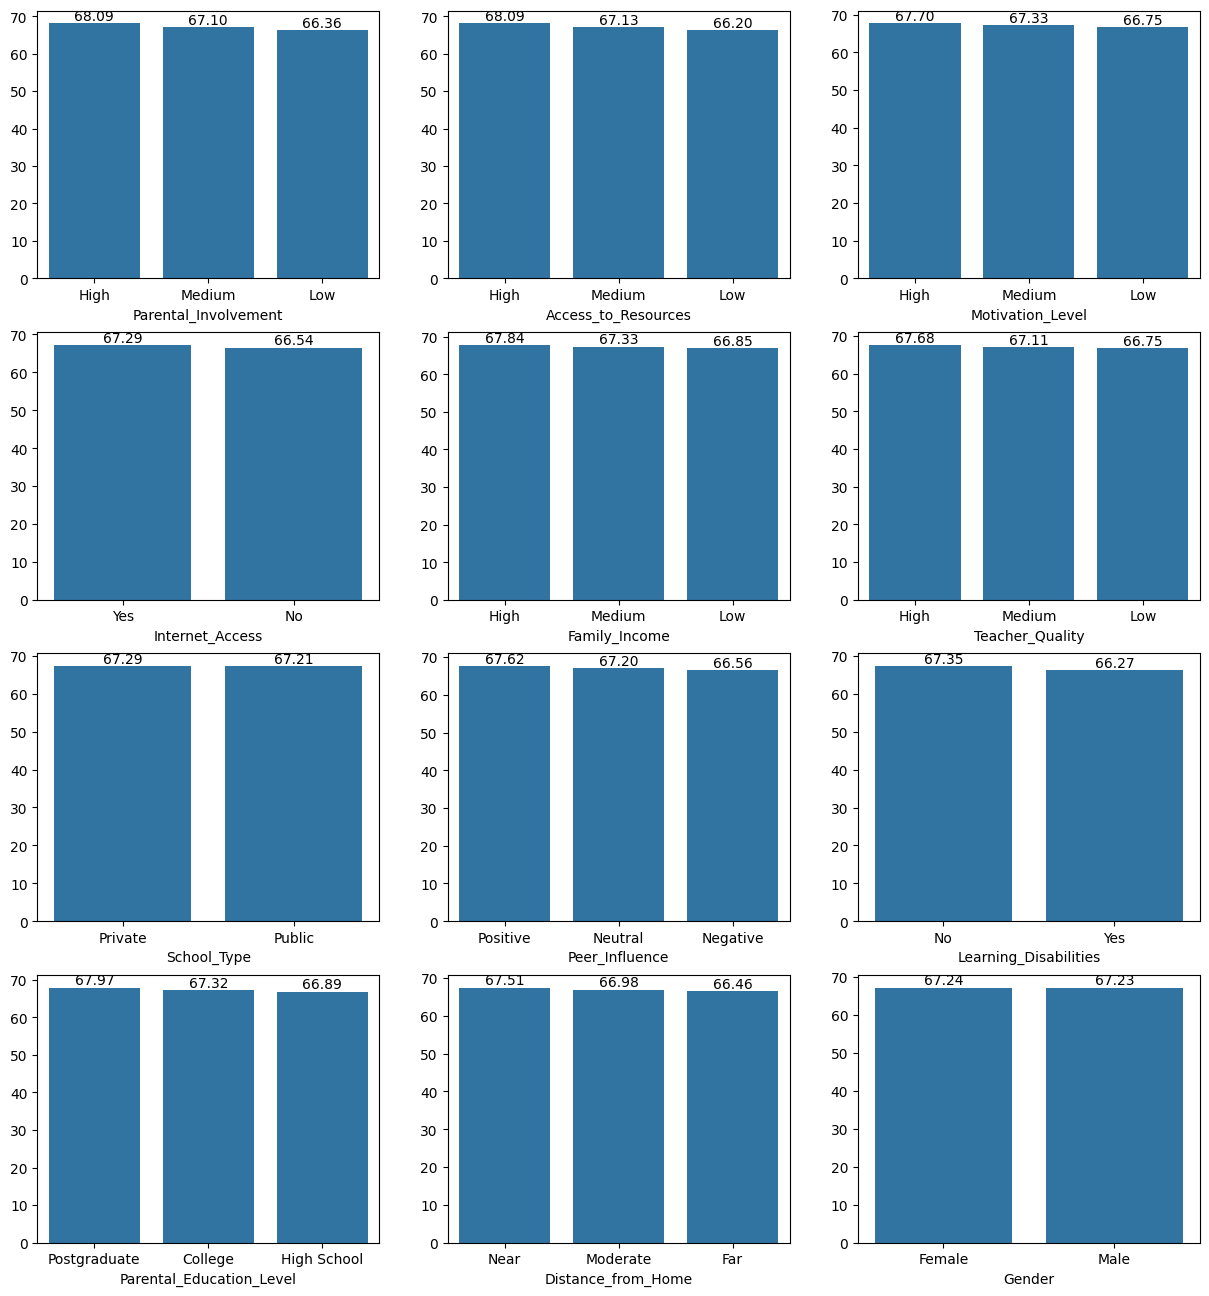

In [122]:

correlations = df.corr(numeric_only=True, method='spearman')['Exam_Score'].sort_values(ascending=False)
print(correlations)


cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 
            'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 
            'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 
            'Distance_from_Home', 'Gender']


n_col = 3
n_row = (len(cat_cols) + n_col - 1) // n_col
plt.figure(figsize=(5*n_col, 4*n_row))
for i, col in enumerate(cat_cols):
    mean_cat = round(df.groupby(col)['Exam_Score'].mean().sort_values(ascending=False), 2)
    ax = plt.subplot(n_row, n_col, i+1)
    sns.barplot(x=mean_cat.index, y=mean_cat.values, ax = ax, legend=False)
    ax.bar_label(ax.containers[0], fmt='%.2f')

### Наблюдения
Анализ на монотонную связь по методу Спирмена, для числовых данных

Наибольшая положительная связь прослежавается по посещаемости и подготове к занятиям, остальные числовые категории имеют слабую взаимосвязь, которая практически отсутствует.

Анализ категориальных признаков на предмет линейной связи с итоговой оценкой.

Четкой выраженной связи среди категориальных признаков нет, тем не менее разница между лутшими и ходшими результатами по категориям состовляет 1- 2 балла, что говорит о умеренном влиянии этих факторов на экзаменационные результаты. Наибольшее влияние на оценки, среди категориальных признаков, оказывают поддержка родителей и доступ к ресурсам.


### Какие переменные имеют распределение, близкое к нормальному?

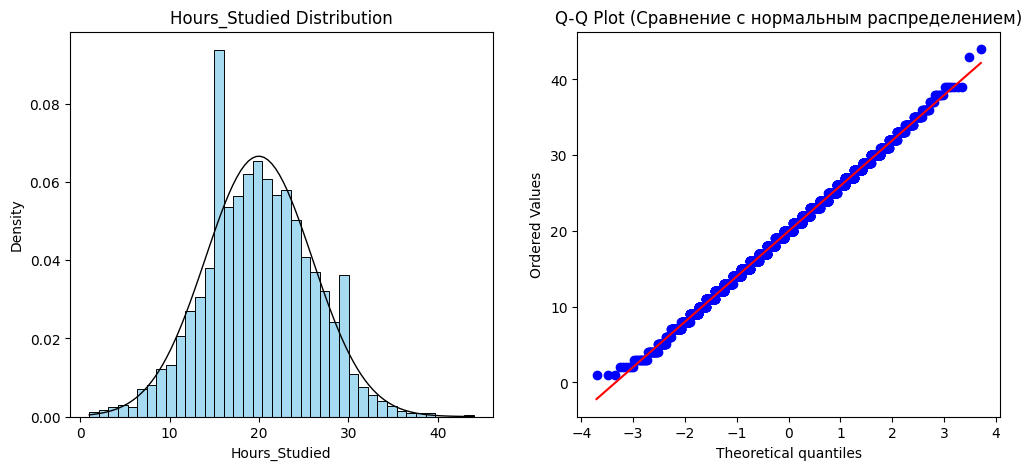

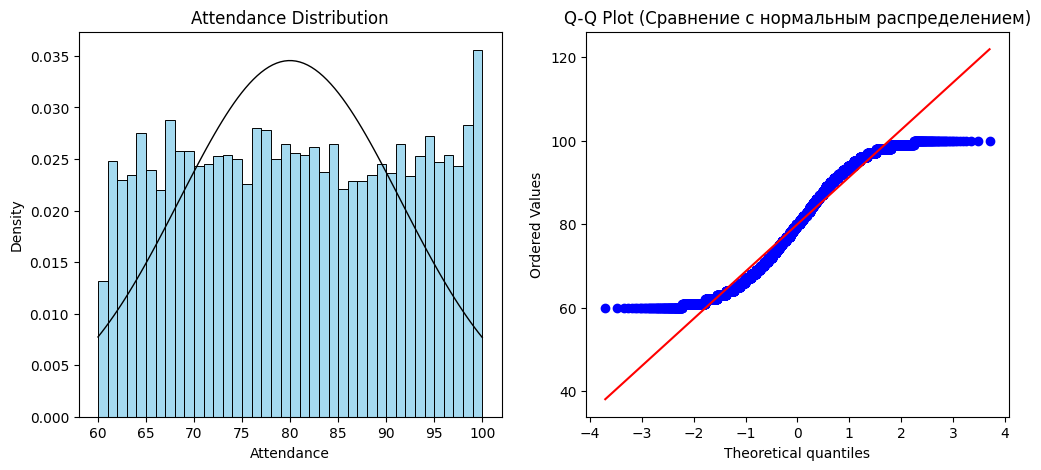

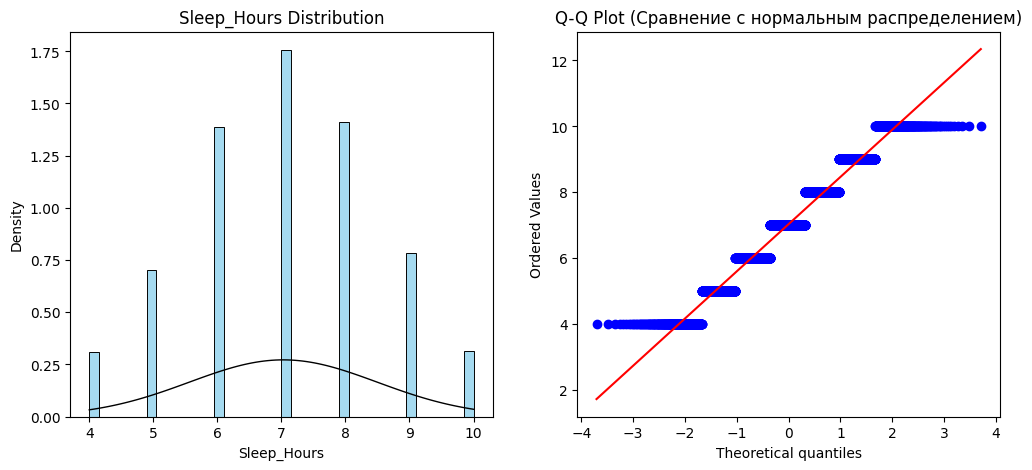

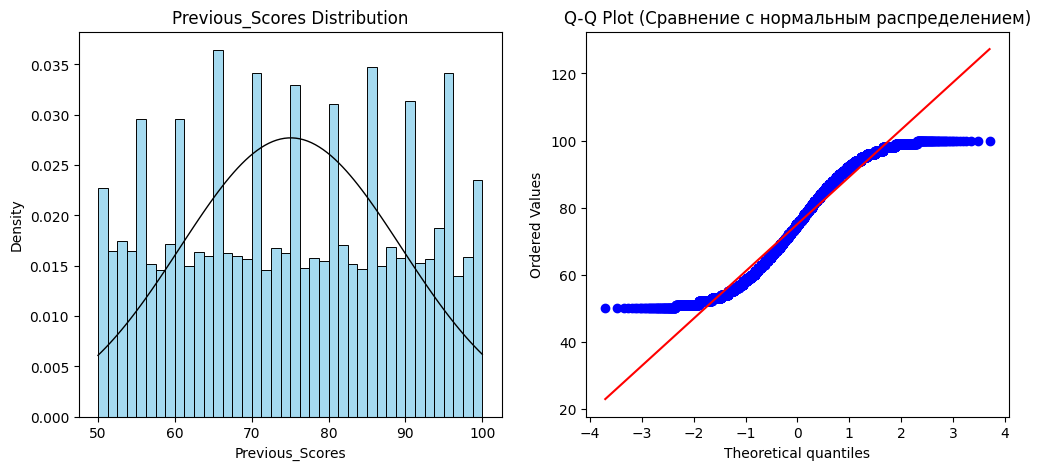

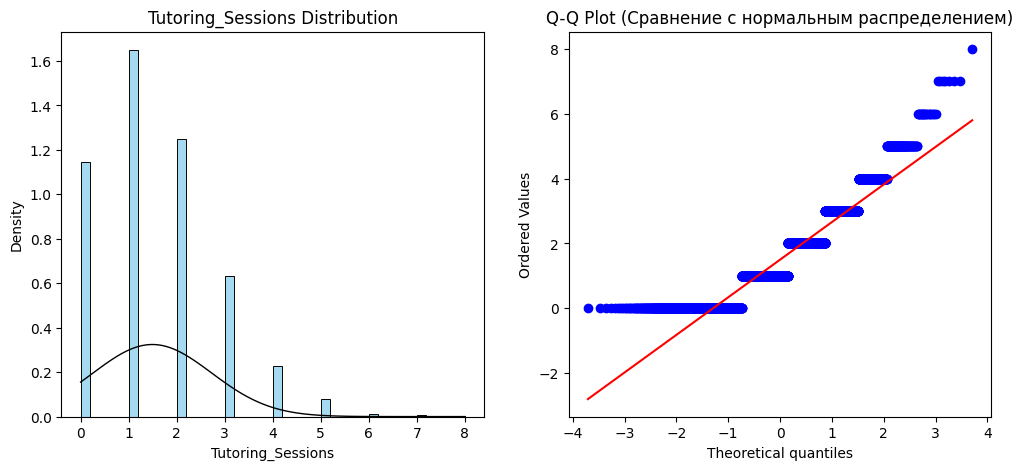

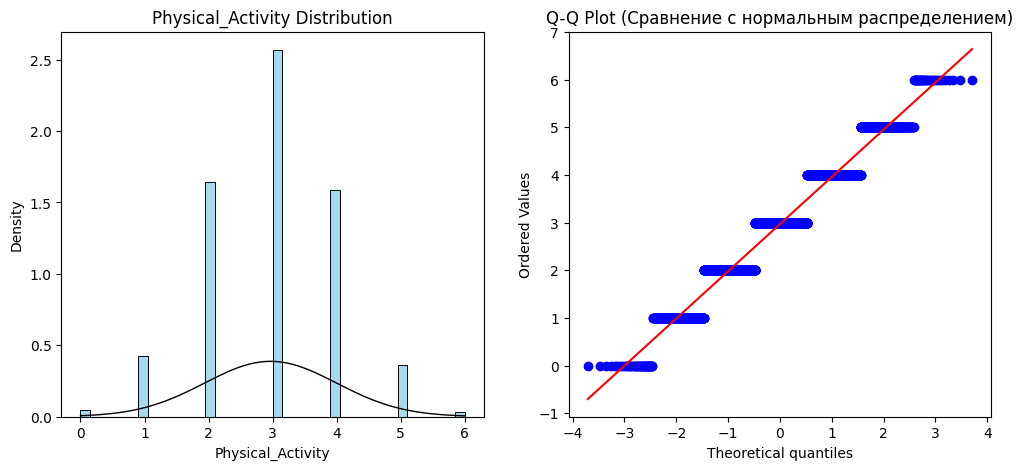

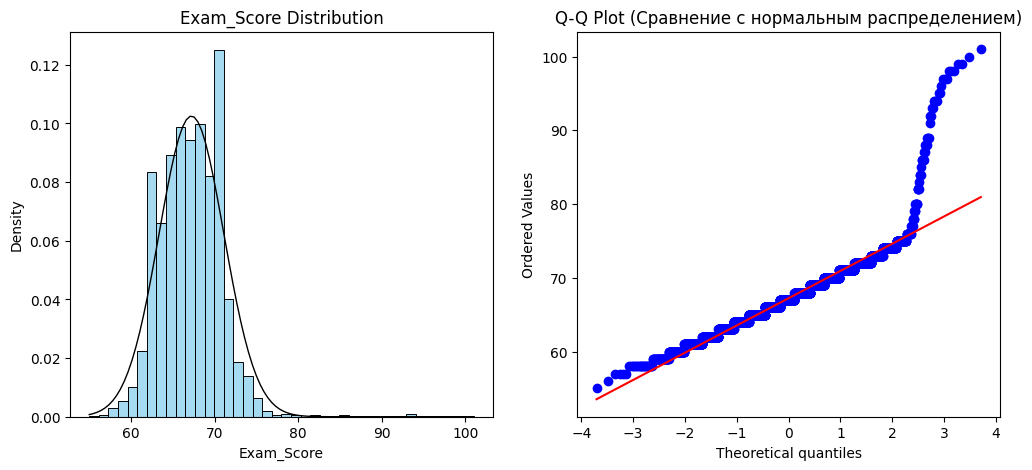

In [123]:
from scipy.stats import norm

numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
                'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


for col in numeric_cols: 
    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    sns.histplot(x=col, data=df, bins=40, color='SkyBlue', stat='density')
    
    mu = df[col].mean()
    sigma = df[col].std()
    x = np.linspace(df[col].min(), df[col].max(), 100)
    plt.plot(x, norm.pdf(x, mu, sigma), color='black', lw=1, label='Normal Distribution')
    plt.title(f'{col} Distribution')
    
    plt.subplot(1,2,2)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title('Q-Q Plot (Сравнение с нормальным распределением)')



### Наблюдения

На основе визуального анализа гистограмм и графиков Q-Q Plot можно сделать вывод о характере распределения исследуемых признаков.

- Hours_Studied (Подготовка к занятиям) и Exam_Score (Итоговый балл) демонстрируют распределение, наиболее близкое к нормальному. Это подтверждается тем, что на графиках Q-Q Plot точки выстраиваются почти в идеальную прямую линию, а гистограммы имеют классическую форму «колокола». Такие данные наиболее предсказуемы для дальнейшего статистического анализа.

- Attendance (Посещаемость) и Previous_Scores (Предыдущие оценки) имеют распределение, близкое к равномерному. В этих данных нет ярко выраженного среднего значения, вокруг которого группировались бы результаты - студенты распределены по шкале этих признаков практически одинаково часто на каждом интервале.

- Tutoring_Sessions (Занятия с репетитором) показывает асимметричное (смещенное) распределение. Большинство студентов либо не посещают дополнительные занятия, либо посещают их редко, что создает «хвост» в сторону более высоких значений.

- Такие показатели, как Sleep_Hours (Сон) и Physical_Activity (Спорт), имеют симметричный вид, но из-за своей дискретной природы (целых чисел) распределены «ступенчато», хотя в целом также стремятся к нормальному виду.

### Общий вывод

В целом можно сказать, что на оценку влияют множество факторов, но ни один из них не являеться доминирующим. В ходе исследования мы обнаружили, что переменная Exam_Score слабо зависима от конкретных переменных, но в то же всремя имеет небольшую корреляцию со всеми другими переменными из датасета.

### В распределении значений каких метрических переменных наблюдается асимметрия?

### Наблюдения
Наиболее ярко выраженна ассиметрия у Tutoring_Sessions (Занятия с репетитором) и Exam_Score. В них наблюдается четкая положительная правостороняя ассиметрия, большинство значений сосредоточенно в левой части графика а вправо уходит длинных хвост. Данные подтверждаются как столбчатыми диаграмами, так и Q-Q plot.

## Описание применения генеративной модели

**1. Объем использования:**  
Для подготовки данной работы генеративная модель использовалась частично, в основном для структурирования текста, уточнения формулировок и помощи в систематизации выводов. Основной анализ, расчеты и интерпретация данных были выполнены автором самостоятельно.

**2. Цели и способ применения:**  
- При составлении описательных выводов по статистическим показателям использовались предложения и формулировки, сгенерированные нейросетью, которые затем редактировались и адаптировались автором под конкретные результаты исследования.  
- Таблицы, расчеты корреляций, построение графиков и интерпретация результатов выполнены вручную с использованием Python и библиотек pandas, seaborn и scipy.  
- Использование модели носило консультативный характер, помогая структурировать текст и проверять формулировки, без автоматической генерации целых разделов.  

**3. Данные о модели:**  
- Название модели: **ChatGPT (GPT-5 mini)**  
- Сайт/источник: [https://chat.openai.com](https://chat.openai.com)  
- Дополнительно для справки и консультаций использовался инструмент: Google Notebook LM  

**4. Оценка эффективности:**  
Применение генеративной модели позволило ускорить работу над формулировками, проверить стилистическую структуру текста и уточнить формулировки выводов. Влияние на исследовательскую часть было минимальным: все расчеты, визуализация и аналитические заключения выполнены автором самостоятельно. Использование ИИ помогло повысить ясность и структурированность текста, не влияя на содержание анализа.

# Дополнительные источники данных
https://sky.pro/wiki/analytics/kak-delaetsya-analiz-poshagovoe-rukovodstvo-dlya-nachinayushchih/


https://habr.com/ru/companies/otus/articles/752434/
